# **Hybrid Multi-Objective Metaheuristic Machine Learning for Pandemic Modeling - Hyper Parameter Tuning Using Genetic Algorithm Optimizer (Part 1)**

### Import Libraries

In [ ]:
!pip install pyswarms
!pip install sklearn-genetic
!pip install shap
!pip install -U pymoo
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.2 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=d5c7a2149ea33fbc990ee235859324ac1846cecadfdd77b3f068faa704783278
  Stored in directory: /root/.cache/pip/wheels/ee/3b/0b/1b865800e916d671a24028d884698674138632a83fdfad4926
Successfully built grapheme
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py)

In [ ]:
import pandas as pd
import numpy as np
import random

import pyswarms as ps
import pyswarms.backend as ps_back
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import ensemble
from sklearn.inspection import permutation_importance
from statistics import mean
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import explained_variance_score,r2_score,median_absolute_error,mean_squared_error,mean_absolute_error
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from lime.lime_tabular import LimeTabularExplainer

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn import metrics

from genetic_selection import GeneticSelectionCV

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.soo.nonconvex.pso import PSO
from pymoo.algorithms.soo.nonconvex.brkga import BRKGA
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.util.running_metric import RunningMetricAnimation
from pymoo.util.running_metric import RunningMetric

from pymoo.core.duplicate import ElementwiseDuplicateElimination
from pymoo.core.mutation import Mutation

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.visualization.scatter import Scatter
from pymoo.termination import get_termination
from pymoo.core.problem import Problem

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

### Initialize & Declaration of Variables

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# set working folder of Google Drive
folder_drive = '/content/drive/MyDrive/Dokument S3 Bismillah/Data/'

# get filename of dataset
dataset_file = 'mergerlengkap_10022025.xlsx'

In [ ]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# read dataset from dataset file
dataset = pd.read_excel(folder_drive + dataset_file)
dataset

,date,mortality_rate,positive_rate,recovery_rate,workplaces,close_ihsg,close_idr,open_ihsg,open_idr,BOR,medical_personnel,number_vaccinations,retail_recreation,grocery_pharmacy,parks,transit_stations,residential,inflation_yoy,BI_rate,bansos,minimum_wage
0,2020-03-03,1,3,0,5,5518,14220,5431,14220,23081,63098,0,3,17,-1,3,0,3.22,4.75,39678600000,4267349
1,2020-03-04,1,0,0,4,5650,14199,5524,14275,23081,63098,0,-2,4,-8,1,1,3.22,4.75,39678600000,4267349
2,2020-03-05,3,4,0,5,5638,14256,5688,14255,23081,63098,0,3,8,1,4,0,3.22,4.75,39678600000,4267349
3,2020-03-06,3,0,0,8,5498,14309,5575,14462,23081,63098,0,10,11,19,5,0,3.22,4.75,39678600000,4267349
4,2020-03-07,3,0,0,7,5498,14309,5575,14462,23081,63098,0,4,12,15,6,-1,3.22,4.75,39678600000,4267349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
952,2022-10-11,15603,738,1411650,-8,6939,15343,6994,15343,23780,45552,10803800,-16,-3,-13,-23,7,4.47,4.25,528960000000,4641854
953,2022-10-12,15603,752,1412072,-7,6909,15338,6939,15338,23780,45552,10804263,-13,-2,-3,-23,6,4.47,4.25,528960000000,4641854
954,2022-10-13,15605,708,1412824,-6,6880,15318,6909,15318,23780,45552,10804726,-16,-6,-12,-24,6,4.47,4.25,528960000000,4641854
955,2022-10-14,15606,612,1413399,-4,6814,15364,6880,15364,23780,45552,10805361,-6,5,9,-22,6,4.47,4.25,528960000000,4641854


## **Dataset Preparation**

### Read Dataset

In [ ]:
# get economy features from the dataset
economy_features = dataset[['inflation_yoy','BI_rate','bansos','minimum_wage']]
n_dim_economy_features = len(economy_features.columns)
economy_features_name = economy_features.columns.values
economy_features

,inflation_yoy,BI_rate,bansos,minimum_wage
0,3.22,4.75,39678600000,4267349
1,3.22,4.75,39678600000,4267349
2,3.22,4.75,39678600000,4267349
3,3.22,4.75,39678600000,4267349
4,3.22,4.75,39678600000,4267349
...,...,...,...,...
952,4.47,4.25,528960000000,4641854
953,4.47,4.25,528960000000,4641854
954,4.47,4.25,528960000000,4641854
955,4.47,4.25,528960000000,4641854


In [ ]:
# get economy features from the dataset
economy_features2 = dataset[['close_ihsg','close_idr','open_ihsg','open_idr']]
n_dim_economy_features2 = len(economy_features.columns)
economy_features_name2 = economy_features.columns.values
economy_features2

,close_ihsg,close_idr,open_ihsg,open_idr
0,5518,14220,5431,14220
1,5650,14199,5524,14275
2,5638,14256,5688,14255
3,5498,14309,5575,14462
4,5498,14309,5575,14462
...,...,...,...,...
952,6939,15343,6994,15343
953,6909,15338,6939,15338
954,6880,15318,6909,15318
955,6814,15364,6880,15364


In [ ]:
diff_ihsg = economy_features2['close_ihsg'] - economy_features2['open_ihsg']
diff_idr = economy_features2['close_idr'] - economy_features2['open_idr']

economy_features_target = pd.DataFrame({'diff_ihsg': diff_ihsg, 'diff_idr': diff_idr})
n_dim_economy_features_target = len(economy_features_target.columns)
economy_features_target_name = economy_features_target.columns.values

economy_features_target

,diff_ihsg,diff_idr
0,87,0
1,126,-76
2,-50,1
3,-77,-153
4,-77,-153
...,...,...
952,-55,0
953,-30,0
954,-29,0
955,-66,0


In [ ]:
# get mobility features from the dataset
mobility_features = dataset[['retail_recreation','grocery_pharmacy','parks','transit_stations','residential']]
n_dim_mobility_features = len(mobility_features.columns)
mobility_features_name = mobility_features.columns.values

mobility_features

,retail_recreation,grocery_pharmacy,parks,transit_stations,residential
0,3,17,-1,3,0
1,-2,4,-8,1,1
2,3,8,1,4,0
3,10,11,19,5,0
4,4,12,15,6,-1
...,...,...,...,...,...
952,-16,-3,-13,-23,7
953,-13,-2,-3,-23,6
954,-16,-6,-12,-24,6
955,-6,5,9,-22,6


In [ ]:
mobility_features_target = dataset[['workplaces']]
n_dim_mobility_features_target = len(mobility_features_target.columns)
mobility_features_target_name = mobility_features_target.columns.values

mobility_features_target

,workplaces
0,5
1,4
2,5
3,8
4,7
...,...
952,-8
953,-7
954,-6
955,-4


In [ ]:
# get health features from the dataset
health_features = dataset[['BOR','medical_personnel','number_vaccinations']]
n_dim_health_features = len(health_features.columns)
health_features_name = health_features.columns.values

health_features

,BOR,medical_personnel,number_vaccinations
0,23081,63098,0
1,23081,63098,0
2,23081,63098,0
3,23081,63098,0
4,23081,63098,0
...,...,...,...
952,23780,45552,10803800
953,23780,45552,10804263
954,23780,45552,10804726
955,23780,45552,10805361


In [ ]:
# get health features from the dataset
health_features_target = dataset[['mortality_rate','positive_rate','recovery_rate']]
n_dim_health_features_target = len(health_features_target.columns)
health_features_target_name = health_features_target.columns.values

health_features_target

,mortality_rate,positive_rate,recovery_rate
0,1,3,0
1,1,0,0
2,3,4,0
3,3,0,0
4,3,0,0
...,...,...,...
952,15603,738,1411650
953,15603,752,1412072
954,15605,708,1412824
955,15606,612,1413399


### Determine The Dependent Variables (X1...Xn)

In [ ]:
X_features = [health_features, mobility_features, economy_features]
X_features = pd.concat(X_features, axis=1, join="inner")
n_dim_X_features = len(X_features.columns)
X_features_name = X_features.columns.values

X_features

,BOR,medical_personnel,number_vaccinations,retail_recreation,grocery_pharmacy,parks,transit_stations,residential,inflation_yoy,BI_rate,bansos,minimum_wage
0,23081,63098,0,3,17,-1,3,0,3.22,4.75,39678600000,4267349
1,23081,63098,0,-2,4,-8,1,1,3.22,4.75,39678600000,4267349
2,23081,63098,0,3,8,1,4,0,3.22,4.75,39678600000,4267349
3,23081,63098,0,10,11,19,5,0,3.22,4.75,39678600000,4267349
4,23081,63098,0,4,12,15,6,-1,3.22,4.75,39678600000,4267349
...,...,...,...,...,...,...,...,...,...,...,...,...
952,23780,45552,10803800,-16,-3,-13,-23,7,4.47,4.25,528960000000,4641854
953,23780,45552,10804263,-13,-2,-3,-23,6,4.47,4.25,528960000000,4641854
954,23780,45552,10804726,-16,-6,-12,-24,6,4.47,4.25,528960000000,4641854
955,23780,45552,10805361,-6,5,9,-22,6,4.47,4.25,528960000000,4641854


In [ ]:
# define variable X (Normalisasi)
scaler = StandardScaler().fit(X_features)
X = scaler.transform(X_features)
print('Size of X: ', X.shape)
n_dim_X = X.shape[1]
n_par_X = X.shape[0]

X

Size of X:  (957, 12)


array([[-1.46561465,  1.09667214, -0.96661031, ...,  2.72153265,
        -1.46560154, -1.14420934],
       [-1.46561465,  1.09667214, -0.96661031, ...,  2.72153265,
        -1.46560154, -1.14420934],
       [-1.46561465,  1.09667214, -0.96661031, ...,  2.72153265,
        -1.46560154, -1.14420934],
       ...,
       [ 0.68230759, -1.41466232,  1.32222631, ...,  1.34639709,
         0.67653589,  1.38433087],
       [ 0.68230759, -1.41466232,  1.32236083, ...,  1.34639709,
         0.67653589,  1.38433087],
       [ 0.68230759, -1.41466232,  1.32247035, ...,  1.34639709,
         0.67653589,  1.38433087]])

### Determine The Independent Variables (Y1...Yn)

In [ ]:
Y_features = [health_features_target, mobility_features_target, economy_features_target]
Y_features = pd.concat(Y_features, axis=1, join="inner")
n_dim_Y_features = len(Y_features.columns)
Y_features_name = Y_features.columns.values

Y_features

,mortality_rate,positive_rate,recovery_rate,workplaces,diff_ihsg,diff_idr
0,1,3,0,5,87,0
1,1,0,0,4,126,-76
2,3,4,0,5,-50,1
3,3,0,0,8,-77,-153
4,3,0,0,7,-77,-153
...,...,...,...,...,...,...
952,15603,738,1411650,-8,-55,0
953,15603,752,1412072,-7,-30,0
954,15605,708,1412824,-6,-29,0
955,15606,612,1413399,-4,-66,0


In [ ]:
Y1_features = Y_features[['positive_rate']]
n_dim_Y1_features = len(Y1_features.columns)
Y1_features_name = Y1_features.columns.values[0]

Y1_features

,positive_rate
0,3
1,0
2,4
3,0
4,0
...,...
952,738
953,752
954,708
955,612


In [ ]:
Y2_features = Y_features[['mortality_rate']]
n_dim_Y2_features = len(Y2_features.columns)
Y2_features_name = Y2_features.columns.values[0]

Y2_features

,mortality_rate
0,1
1,1
2,3
3,3
4,3
...,...
952,15603
953,15603
954,15605
955,15606


In [ ]:
Y3_features = Y_features[['recovery_rate']]
n_dim_Y3_features = len(Y3_features.columns)
Y3_features_name = Y3_features.columns.values[0]

Y3_features

,recovery_rate
0,0
1,0
2,0
3,0
4,0
...,...
952,1411650
953,1412072
954,1412824
955,1413399


In [ ]:
Y4_features = Y_features[['diff_idr']]
n_dim_Y4_features = len(Y4_features.columns)
Y4_features_name = Y4_features.columns.values[0]

Y4_features

,diff_idr
0,0
1,-76
2,1
3,-153
4,-153
...,...
952,0
953,0
954,0
955,0


In [ ]:
Y5_features = Y_features[['diff_ihsg']]
n_dim_Y5_features = len(Y5_features.columns)
Y5_features_name = Y5_features.columns.values[0]

Y5_features

,diff_ihsg
0,87
1,126
2,-50
3,-77
4,-77
...,...
952,-55
953,-30
954,-29
955,-66


In [ ]:
Y6_features = Y_features[['workplaces']]
n_dim_Y6_features = len(Y6_features.columns)
Y6_features_name = Y6_features.columns.values[0]

Y6_features

,workplaces
0,5
1,4
2,5
3,8
4,7
...,...
952,-8
953,-7
954,-6
955,-4


## **COVID-19 Predictor Creation**

In [ ]:
def scale_data(df):
  scaler = StandardScaler().fit(df)
  d = scaler.transform(df)

  return d, scaler

In [ ]:
# n is the number of trees in the forest in the range [5, 50]. d is the maximum depth of the tree to grow in the range [5, 50]. s is the minimum number of data to split
# an internal node in the range [2, 50]. l is the minimum number of data to gain a leaf node in the range [1, 20]. w is the size of the rolling time-window defned by the
# integer {3, 5, 7} (Y. Pan et al., 2021, p. 8)
def create_population(pop_size):
  population = []
  for i in range(pop_size):
      n = random.randint(5, 50)
      d = random.randint(5, 50)
      s = random.randint(2, 50)
      l = random.randint(1, 20)
      w = random.choice([3,5,7])

      population.append([float(n), float(d), float(s), float(l), float(w)])

  return population

In [ ]:
# rolling time-window in the size of n days is designed in random forest regression to model and predict the target objectives over time (Y. Pan et al., 2021, p. 7)
def create_rolling_time_window(df, w):
  df = df.rolling(window=w).mean()
  df = df.dropna()

  return df

### K-Fold Cross Validation

In [ ]:
def split_data(cv, D):
  D_train = []
  D_test = []

  for i, (train, test) in enumerate(cv.split(D)):
    D_train.append(train)
    D_test.append(test)

  return D_train, D_test

In [ ]:
def KFold_process(X, Y, n):
  cv = KFold(n_splits=n, random_state=1, shuffle=True)
  X_train_idx, X_test_idx = split_data(cv, X)
  Y_train_idx, Y_test_idx = split_data(cv, Y)

  X_train = X[X_train_idx[0]]
  X_test = X[X_test_idx[0]]

  Y_train = Y[Y_train_idx[0]]
  Y_test = Y[Y_test_idx[0]]

  return cv, X_train, X_test, Y_train, Y_test

### Model Machine Learning

In [ ]:
def regr_process(X, Y, n, d, s, l):
  # 3-fold cross validation (Y. Pan et al., 2021, p. 3)
  cv, X_train, X_test, Y_train, Y_test = KFold_process(X, Y, 3)
  #X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

  # random forest regression is trained on the prepared dataset to model the non-linear
  # relationship between the input inﬂuential factors and the targeted
  # objective, aiming to conduct the time-series prediction (Y. Pan et al., 2021, p. 3)
  regr = XGBRegressor(n_estimators=n, max_depth=d)
  regr.fit(X_train, Y_train)
  score = regr.score(X_test, Y_test) # score R2 (coefficient of determination (R Squared) of random forest regression model)

  return regr, score

### Hyper Parameter Tuning Using Genetic Algorithm Optimizer

In [ ]:
class XGBR_GAProblem(Problem):
    def __init__(self, X_raw, Y_raw):
        super().__init__(n_var=5, n_obj=1, n_constr=0, xl=np.array([5, 5, 2, 1, 3]), xu=np.array([50, 50, 50, 20, 7]), type_var=int)
        self.X_raw = X_raw
        self.Y_raw = Y_raw

    def _evaluate(self, X, out, *args, **kwargs):
        scores = []
        for row in X:
            n, d, s, l, w = row
            if w not in [3, 5, 7]:
                scores.append(1e6)  # penalti besar untuk window invalid
                continue

            # Rolling + Normalisasi
            try:
                Xr = create_rolling_time_window(self.X_raw.copy(), w)
                Yr = create_rolling_time_window(self.Y_raw.copy(), w)
                X_scaled, _ = scale_data(Xr)
                Y_scaled, _ = scale_data(Yr)
                Y_scaled = np.ravel(Y_scaled)

                _, score = regr_process(X_scaled, Y_scaled, n, d, s, l)
                score = -score if 0 <= score <= 1 else 1e6  # GA minimisasi → balik score
            except:
                score = 1e6  # fallback jika error

            scores.append(score)

        out["F"] = np.array(scores)

### Regressor Model with the Optimal Parameter (Genetic Algorithm Optimizer Result)

In [ ]:
def tuning_param_model_ga(X_raw, Y_raw, generations=30):
    problem = XGBR_GAProblem(X_raw, Y_raw)

    algorithm = GA(
        pop_size=50,
        eliminate_duplicates=True
    )

    result = minimize(
        problem,
        algorithm,
        ('n_gen', generations),
        verbose=True
    )

    best_params = result.X.astype(int)
    best_cost = -result.F[0]

    print('--------------------------------------')
    print('The best cost found by GA is: {:.4f}'.format(best_cost))
    print('The best parameters found by GA are: {}'.format(best_params))

    return best_cost, best_params

In [ ]:
# measure the performance of the (random forest) model with the optimal parameters by MSE, MAE, and MAPE (Y. Pan et al., 2021, p. 4 & 7)
def evaluation(gtrue, pred):
  MAE = metrics.mean_absolute_error(gtrue, pred)
  MSE = metrics.mean_squared_error(gtrue, pred)
  RMSE = np.sqrt(metrics.mean_squared_error(gtrue, pred))
  MAPE = metrics.mean_absolute_percentage_error(gtrue,pred)

  print('--------------------------------------')
  print('Root Mean Squared Error (RMSE): {:.4f}'.format(RMSE))
  print('Mean Squared Error (MSE): {:.4f}'.format(MSE))
  print('Mean Absolute Error (MAE): {:.4f}'.format(MAE))
  print('Mean Absolute Percentage Error (MAPE): {:.4f}'.format(MAPE))

In [ ]:
# define Regressor optimal model
def set_optimal_model(XF,YF,best_cost,best_pos):
  pos = best_pos

  # optimal parameters (PSO result)
  n = int(pos[0])
  d = int(pos[1])
  s = int(pos[2])
  l = int(pos[3])
  w = int(pos[4])
  print('')
  print('Optimal parameter: n={}, d={}, s={}, l={}, w={}'.format(n, d, s, l, w))

  X = create_rolling_time_window(XF, w)
  Y = create_rolling_time_window(YF, w)
  X, scaleX = scale_data(X)
  Y, scaleY = scale_data(Y)
  Y = np.ravel(Y)

  cv, X_train, X_test, Y_train, Y_test = KFold_process(X, Y, 3)
  regr = XGBRegressor(n_estimators=n, max_depth=d)
  regr.fit(X_train, Y_train)
  Y_pred = regr.predict(X_test)

  # performance evaluation of the established random forest regression models with the optimal parameters (Y. Pan et al., 2021, p. 8)
  evaluation(Y_test, Y_pred)

  r_squared = r2_score(Y_test, Y_pred)
  print('R-Squared (R2) Value of model: {:.4f}'.format(r_squared))

  fig = plt.figure()
  ax = fig.add_axes([0, 0, 1, 1])

  # Plot the estimated linear regression line with matplotlib:
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',
          cmap='jet')
  plt.xlabel("Actual Output")
  plt.ylabel("Predicted Output")
  plt.title("XGB Regressor Performance")
  plt.plot(np.unique(Y_test),
          np.poly1d(np.polyfit(Y_test, Y_pred, 1))(np.unique(Y_test)),
          color = "blue",)
  # plt.text(4000, 5500, '$\mathregular{R^2 = %0.2f}$' % r_squared_1, color = "red")

  ax.text(0, 1, '$\mathregular{R^2 = %0.4f}$' %  r_squared,
          color = "red",
          horizontalalignment='left',
          verticalalignment='top',
          transform=ax.transAxes)

  plt.show()

  return regr, X, Y, scaleX, scaleY, X_test, Y_test

## **MAIN PROGRAM HYPER PARAMETER TUNING SECTION**
---



XGBR Optimal Model for POSITIVE_RATE - Variable (Y1):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [ 8 29 32  2  3]

Optimal parameter: n=8, d=29, s=32, l=2, w=3
--------------------------------------
Root Mean Squared Error (RMSE): 0.1914
Mean Squared Error (MSE): 0.0366
Mean Absolute Error (MAE): 0.0981
Mean Absolute Percentage Error (MAPE): 0.3523
R-Squared (R2) Value of model: 0.9624


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


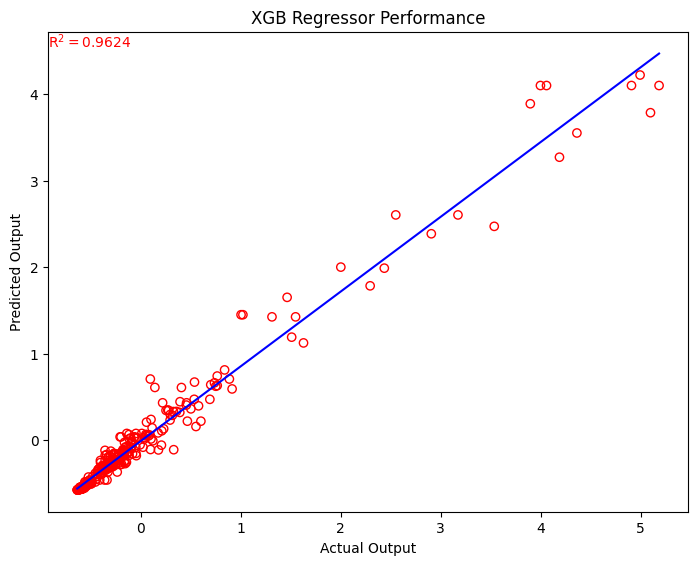

In [ ]:
#two random forest regression models are built (established random forest regression models with the optimal parameters) (Y. Pan et al., 2021, p. 7-8)

#Gradient Boosting Regressor model for [POSITIVE RATE]
print('XGBR Optimal Model for {} - Variable (Y1):'.format(Y1_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF1 = X_features
YF1 = Y1_features

best_costY1, best_posY1 = tuning_param_model_ga(XF1, YF1, iterations) # hyper parameter tuning process
regrY1, X_Y1, Y1, scaleX1, scaleY1, X_test, Y_test = set_optimal_model(XF1, YF1, best_costY1, best_posY1) # optimal model

XGBR Optimal Model for MORTALITY_RATE - Variable (Y2):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [14 31 20  1  4]

Optimal parameter: n=14, d=31, s=20, l=1, w=4
--------------------------------------
Root Mean Squared Error (RMSE): 0.0201
Mean Squared Error (MSE): 0.0004
Mean Absolute Error (MAE): 0.0138
Mean Absolute Percentage Error (MAPE): 0.0369
R-Squared (R2) Value of model: 0.9996


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


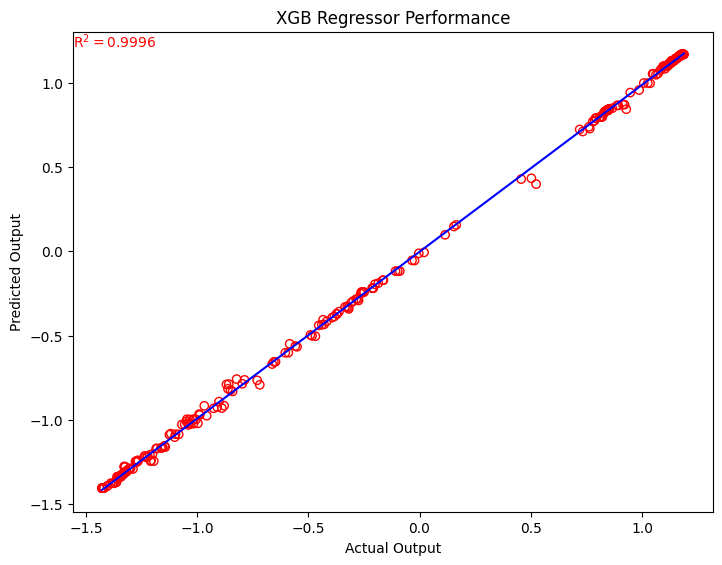

In [ ]:
# Gradient Boosting Regressor model for [MORTALITY RATE]
print('XGBR Optimal Model for {} - Variable (Y2):'.format(Y2_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF2 = X_features
YF2 = Y2_features

best_costY2, best_posY2 = tuning_param_model_ga(XF2, YF2, iterations)  # hyper parameter tuning process
regrY2, X_Y2, Y2, scaleX2, scaleY2, X_test, Y_test = set_optimal_model(XF2, YF2, best_costY2, best_posY2) # optimal model

XGBR Optimal Model for RECOVERY_RATE - Variable (Y3):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [37  7 28  2  5]

Optimal parameter: n=37, d=7, s=28, l=2, w=5


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


--------------------------------------
Root Mean Squared Error (RMSE): 0.0170
Mean Squared Error (MSE): 0.0003
Mean Absolute Error (MAE): 0.0091
Mean Absolute Percentage Error (MAPE): 0.1712
R-Squared (R2) Value of model: 0.9997


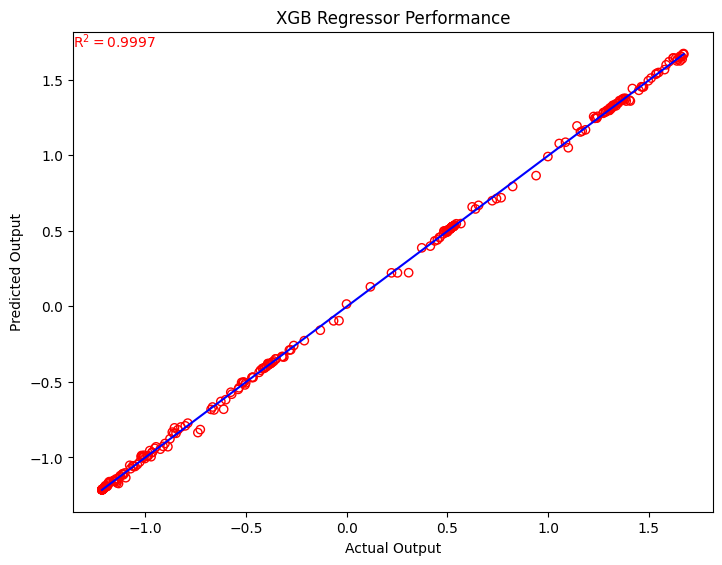

In [ ]:
# Gradient Boosting Regressor model for [RECOVERY RATE]
print('XGBR Optimal Model for {} - Variable (Y3):'.format(Y3_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF3 = X_features
YF3 = Y3_features

best_costY3, best_posY3 = tuning_param_model_ga(XF3, YF3, iterations)  # hyper parameter tuning process
regrY3, X_Y3, Y3, scaleX3, scaleY3, X_test, Y_test = set_optimal_model(XF3, YF3, best_costY3, best_posY3) # optimal model

XGBR Optimal Model for DIFF_IDR - Variable (Y4):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [13 39 22 12  4]

Optimal parameter: n=13, d=39, s=22, l=12, w=4
--------------------------------------
Root Mean Squared Error (RMSE): 0.8343
Mean Squared Error (MSE): 0.6961
Mean Absolute Error (MAE): 0.3959
Mean Absolute Percentage Error (MAPE): 1.8210
R-Squared (R2) Value of model: 0.2778


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


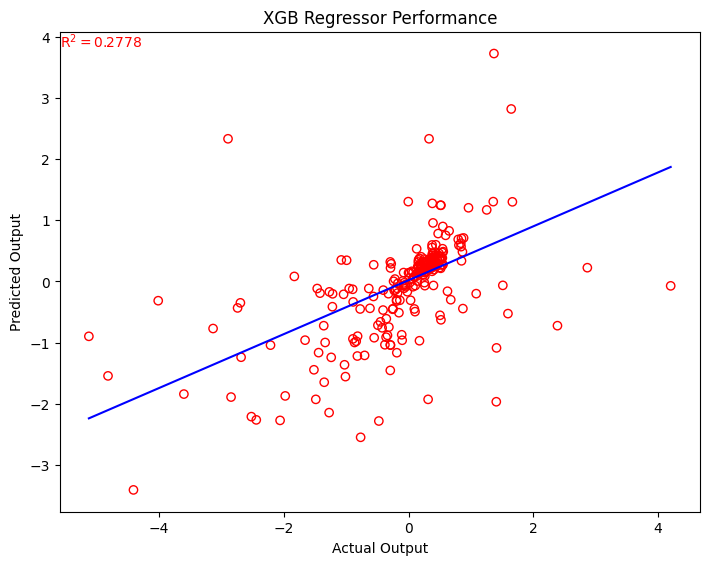

In [ ]:
# Gradient Boosting Regressor model for WORKPLACES]
print('XGBR Optimal Model for {} - Variable (Y4):'.format(Y4_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF4 = X_features
YF4 = Y4_features

best_costY4, best_posY4 = tuning_param_model_ga(XF4, YF4, iterations)  # hyper parameter tuning process
regrY4, X_Y4, Y4, scaleX4, scaleY4, X_test, Y_test = set_optimal_model(XF4, YF4, best_costY4, best_posY4) # optimal model

XGBR Optimal Model for DIFF_IHSG - Variable (Y5):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [39 49 26  6  4]

Optimal parameter: n=39, d=49, s=26, l=6, w=4
--------------------------------------
Root Mean Squared Error (RMSE): 0.8934
Mean Squared Error (MSE): 0.7982
Mean Absolute Error (MAE): 0.6158
Mean Absolute Percentage Error (MAPE): 4.0897
R-Squared (R2) Value of model: 0.3040


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


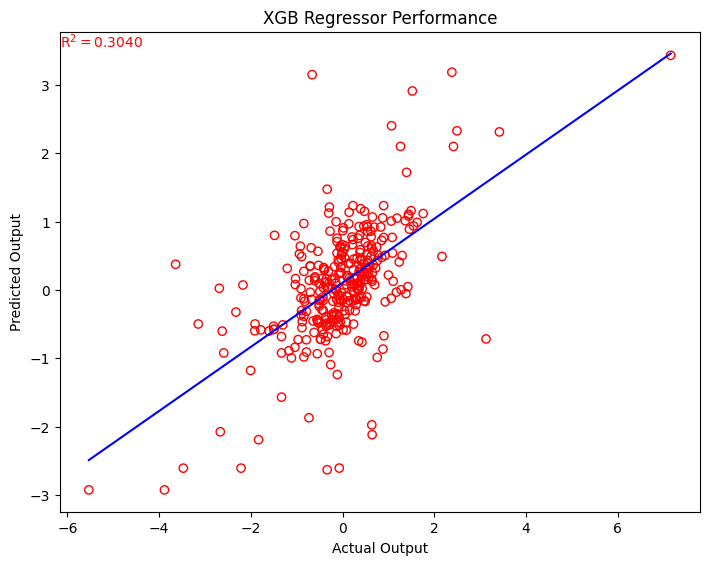

In [ ]:
# Gradient Boosting Regressor model for [DIFFERENCE IDR]
print('XGBR Optimal Model for {} - Variable (Y5):'.format(Y5_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF5 = X_features
YF5 = Y5_features

best_costY5, best_posY5 = tuning_param_model_ga(XF5, YF5, iterations)  # hyper parameter tuning process
regrY5, X_Y5, Y5, scaleX5, scaleY5, X_test, Y_test = set_optimal_model(XF5, YF5, best_costY5, best_posY5) # optimal model

XGBR Optimal Model for WORKPLACES - Variable (Y6):
-----------------------------------------------------------------
n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  1.000000E+06 |  1.000000E+06
     2 |      100 |  1.000000E+06 |  1.000000E+06
--------------------------------------
The best cost found by GA is: -1000000.0000
The best parameters found by GA are: [14 31 33  7  6]

Optimal parameter: n=14, d=31, s=33, l=7, w=6
--------------------------------------
Root Mean Squared Error (RMSE): 0.2693
Mean Squared Error (MSE): 0.0725
Mean Absolute Error (MAE): 0.1506
Mean Absolute Percentage Error (MAPE): 0.6646
R-Squared (R2) Value of model: 0.9339


/tmp/ipython-input-31-3072228168.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(Y_test, Y_pred, facecolors='none', edgecolors='r',


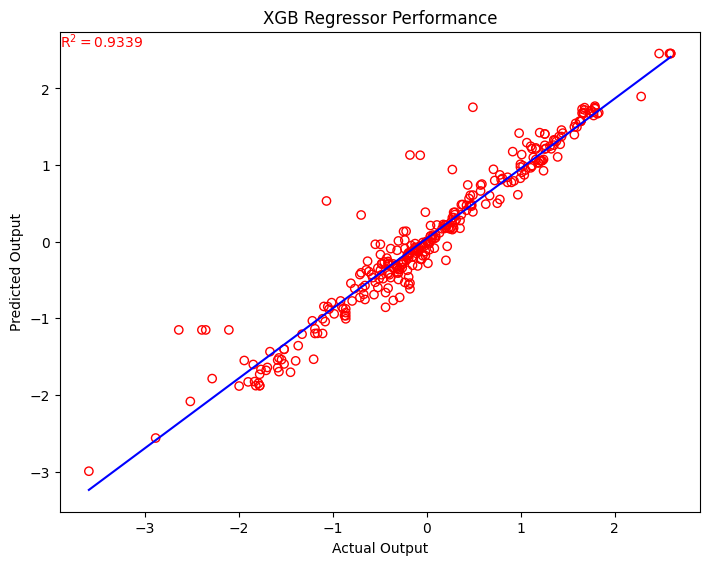

In [ ]:
# Gradient Boosting Regressor model for [DIFFERENCE IHSG]
print('XGBR Optimal Model for {} - Variable (Y6):'.format(Y6_features_name.upper()))
print('-----------------------------------------------------------------')

iterations = 2 # initialize iterations
XF6 = X_features
YF6 = Y6_features

best_costY6, best_posY6 = tuning_param_model_ga(XF6, YF6, iterations)  # hyper parameter tuning process
regrY6, X_Y6, Y6, scaleX6, scaleY6, X_test, Y_test = set_optimal_model(XF6, YF6, best_costY6, best_posY6) # optimal model

### Feature Importance Measurement using Mean Decrease in Impurity (MDI)

In [ ]:
def MDI_process(regr, title, X_features_name, X_test, Y_test):
  feature_importance = regr.feature_importances_
  sorted_idx = np.argsort(feature_importance)
  pos = np.arange(sorted_idx.shape[0]) + 0.5
  fig = plt.figure(figsize=(12, 6))

  result = permutation_importance(
      regr, X_test, Y_test, n_repeats=10, random_state=42, n_jobs=2
  )
  sorted_idx = result.importances_mean.argsort()
  plt.subplot(1, 2, 2)
  plt.boxplot(
      result.importances[sorted_idx].T,
      vert=False,
      labels=np.array(X_features_name)[sorted_idx],
  )
  plt.title(title)
  fig.tight_layout()
  plt.show()

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


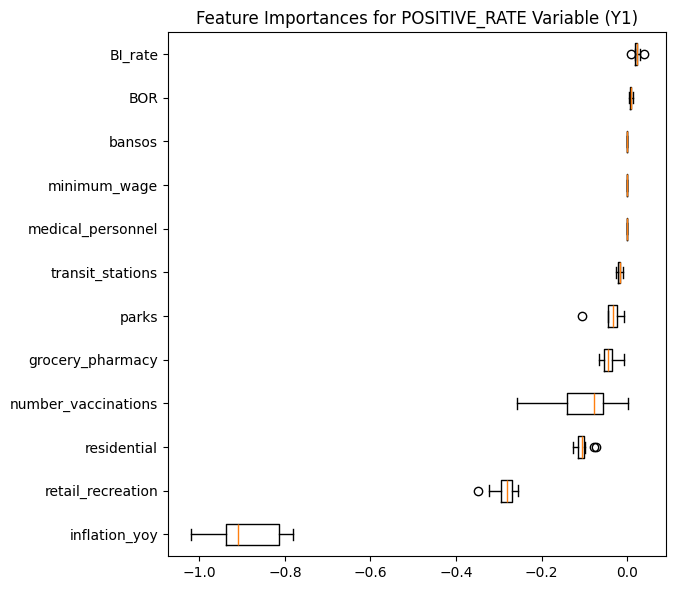

In [ ]:
MDI_process(regrY1, 'Feature Importances for {} {}'.format(Y1_features_name.upper(), 'Variable (Y1)'), X_features_name, X_test, Y_test)

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


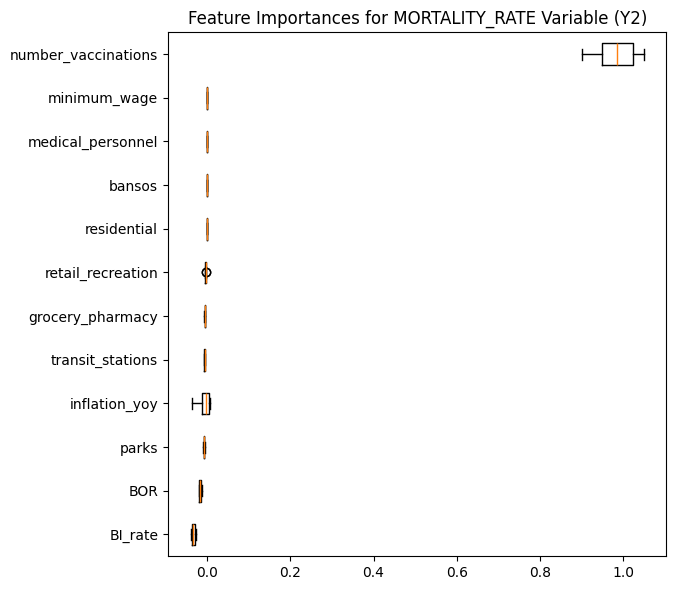

In [ ]:
MDI_process(regrY2, 'Feature Importances for {} {}'.format(Y2_features_name.upper(), 'Variable (Y2)'), X_features_name, X_test, Y_test)

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


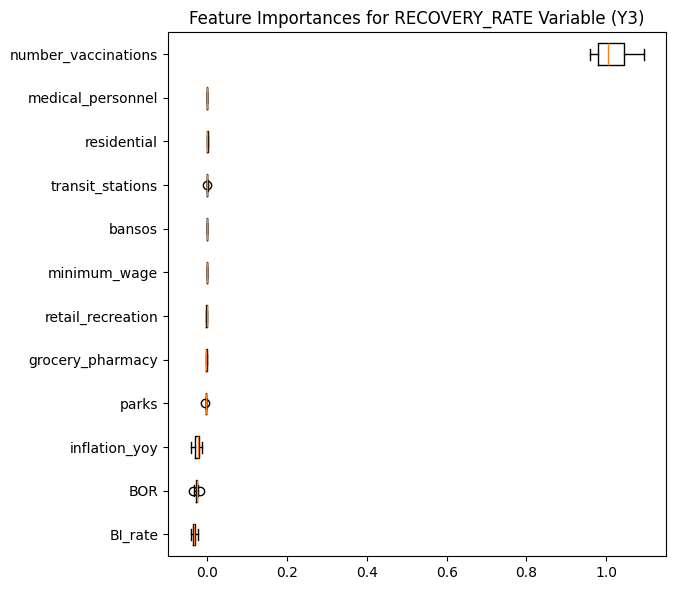

In [ ]:
MDI_process(regrY3, 'Feature Importances for {} {}'.format(Y3_features_name.upper(), 'Variable (Y3)'), X_features_name, X_test, Y_test)

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


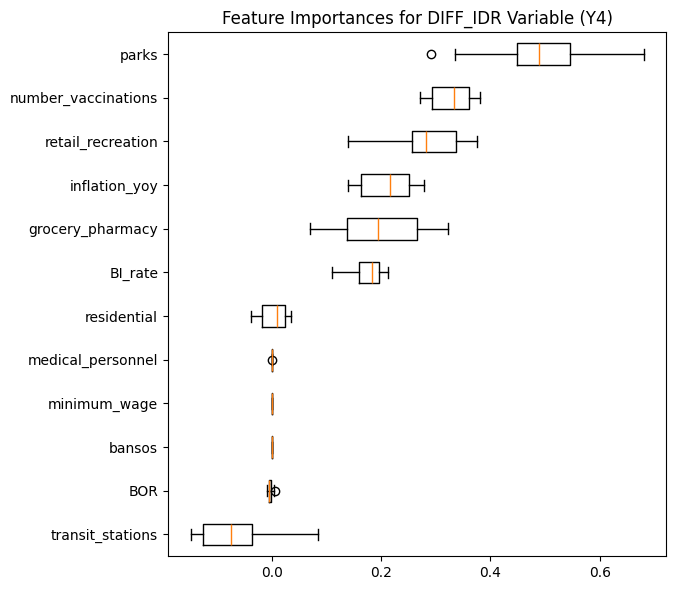

In [ ]:
MDI_process(regrY4, 'Feature Importances for {} {}'.format(Y4_features_name.upper(), 'Variable (Y4)'), X_features_name, X_test, Y_test)

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


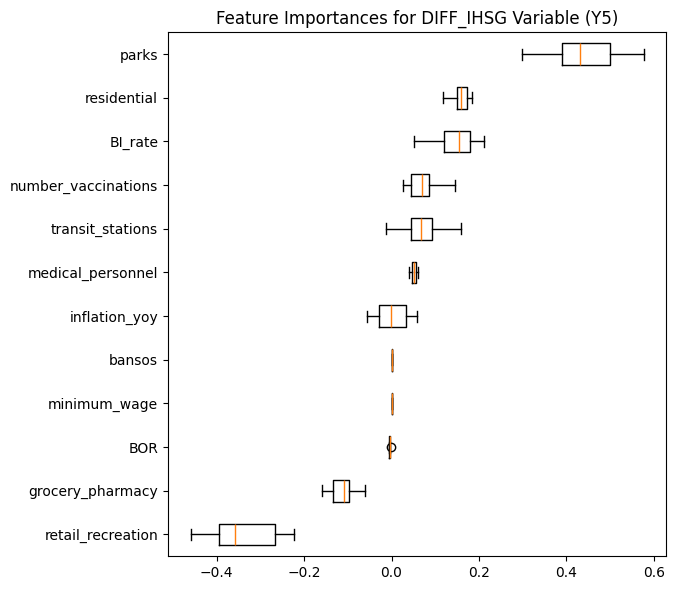

In [ ]:
MDI_process(regrY5, 'Feature Importances for {} {}'.format(Y5_features_name.upper(), 'Variable (Y5)'), X_features_name, X_test, Y_test)

/tmp/ipython-input-38-3672551465.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


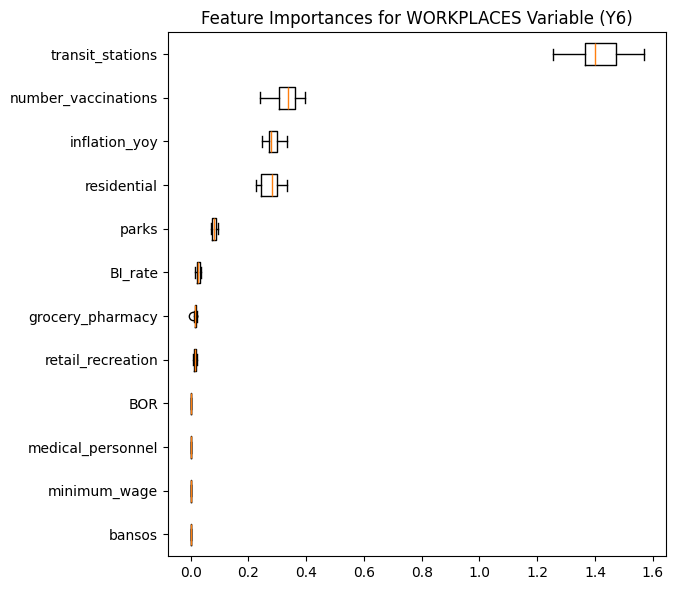

In [ ]:
MDI_process(regrY6, 'Feature Importances for {} {}'.format(Y6_features_name.upper(), 'Variable (Y6)'), X_features_name, X_test, Y_test)

### Feature Importance Measurement using TreeSHAP

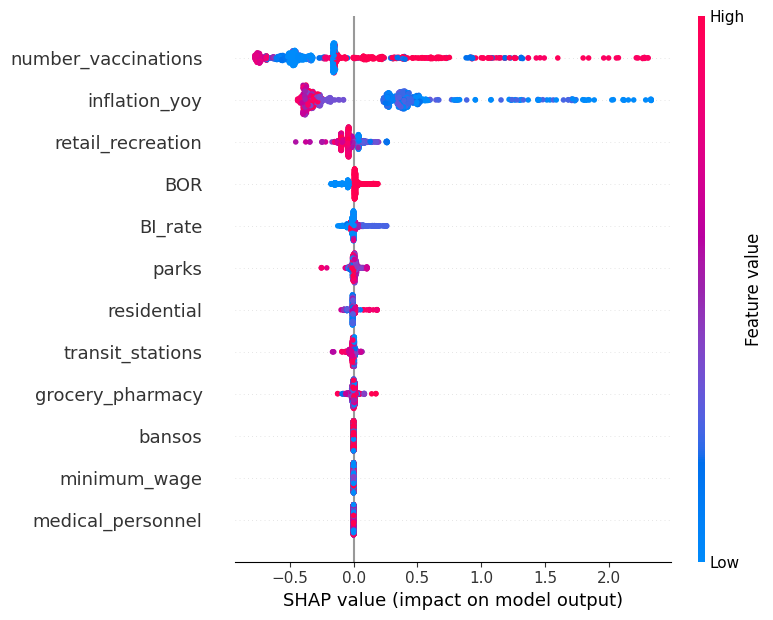

In [ ]:
# Explain with tree SHAP for MORTALITY_RATE Variable (Y1)
explainer_Y1 = shap.TreeExplainer(regrY1)
shap_values_Y1 = explainer_Y1.shap_values(X_Y1)
shap.summary_plot(shap_values_Y1, X_Y1, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y1.expected_value, shap_values_Y1, feature_names=X_features_name)

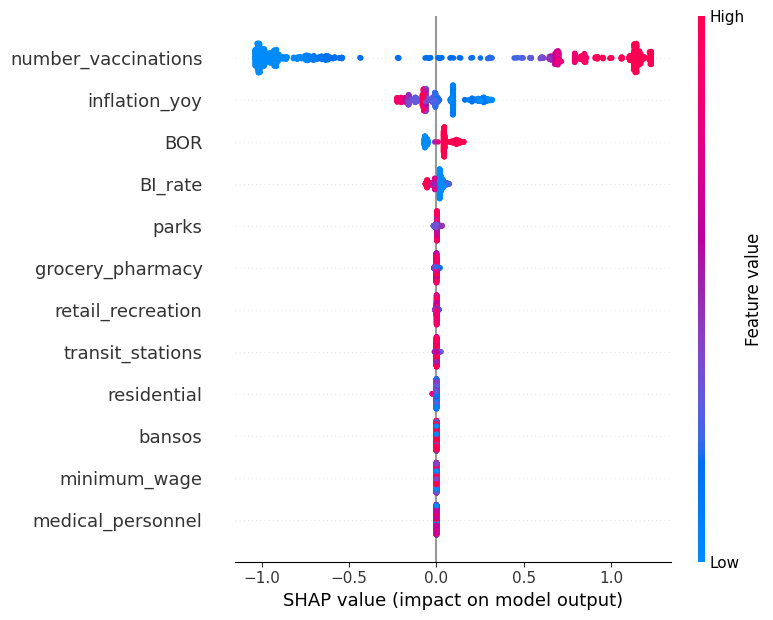

In [ ]:
# Explain with tree SHAP for POSITIVE_RATE Variable (Y2)
explainer_Y2 = shap.TreeExplainer(regrY2)
shap_values_Y2 = explainer_Y2.shap_values(X_Y2)
shap.summary_plot(shap_values_Y2, X_Y2, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y2.expected_value, shap_values_Y2, feature_names=X_features_name)

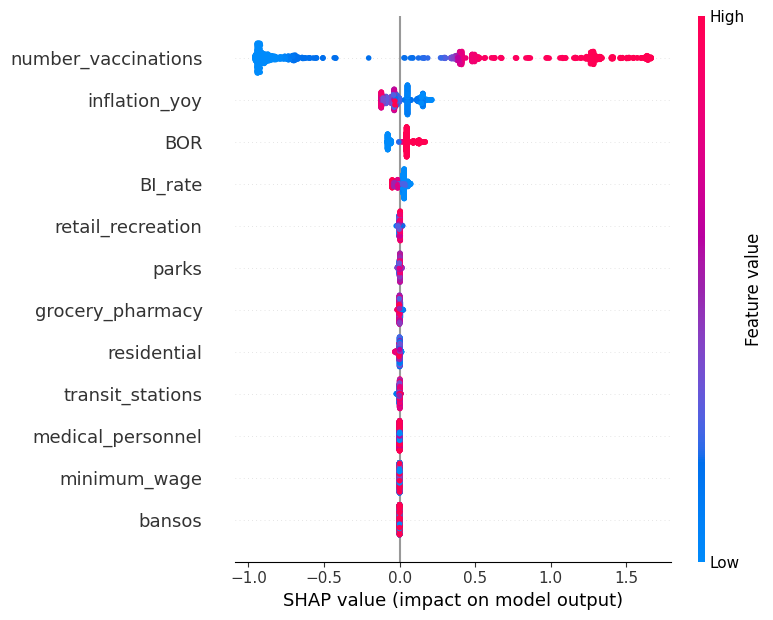

In [ ]:
# Explain with tree SHAP for RECOVERY_RATE Variable (Y3)
explainer_Y3 = shap.TreeExplainer(regrY3)
shap_values_Y3 = explainer_Y3.shap_values(X_Y3)
shap.summary_plot(shap_values_Y3, X_Y3, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y3.expected_value, shap_values_Y3, feature_names=X_features_name)

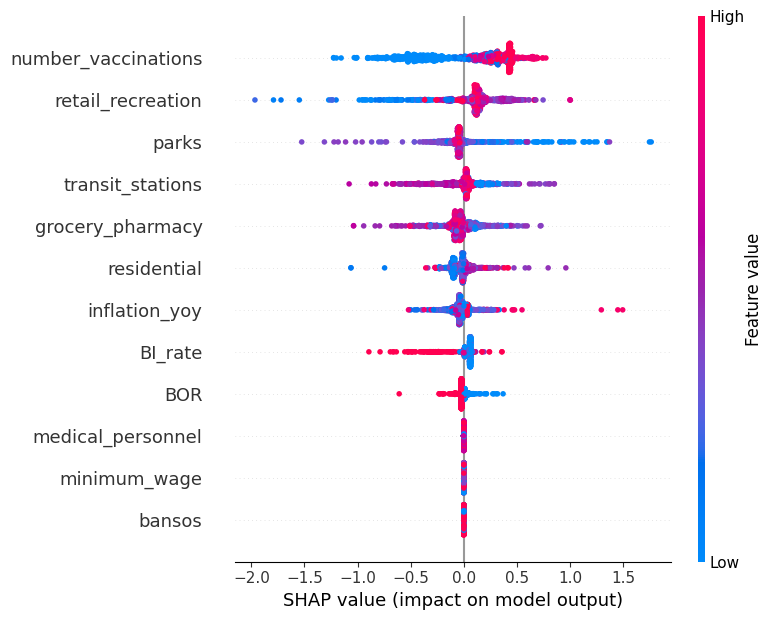

In [ ]:
# Explain with tree SHAP for WORKPLACES Variable (Y4)
explainer_Y4 = shap.TreeExplainer(regrY4)
shap_values_Y4 = explainer_Y4.shap_values(X_Y4)
shap.summary_plot(shap_values_Y4, X_Y4, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y4.expected_value, shap_values_Y4, feature_names=X_features_name)

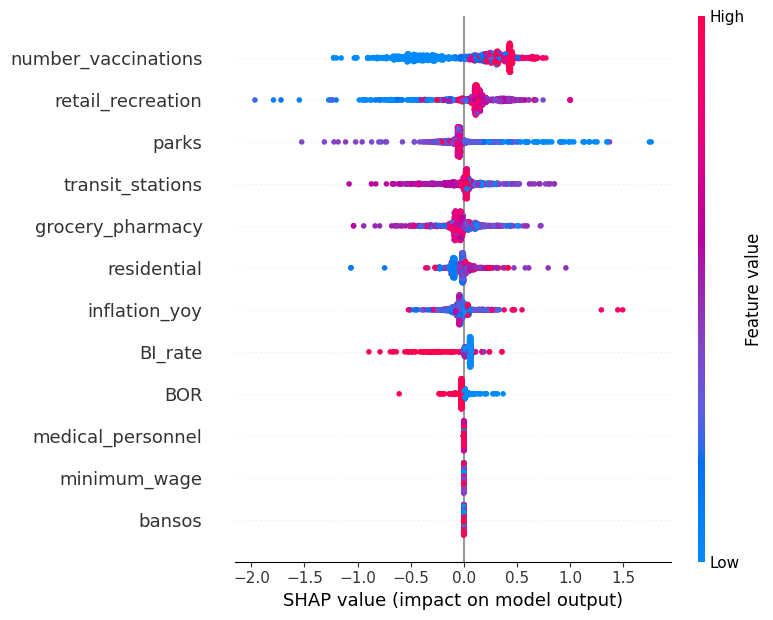

In [ ]:
# Explain with tree SHAP for DIFF_IDR Variable (Y5)
explainer_Y5 = shap.TreeExplainer(regrY5)
shap_values_Y5 = explainer_Y4.shap_values(X_Y5)
shap.summary_plot(shap_values_Y5, X_Y5, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y5.expected_value, shap_values_Y5, feature_names=X_features_name)

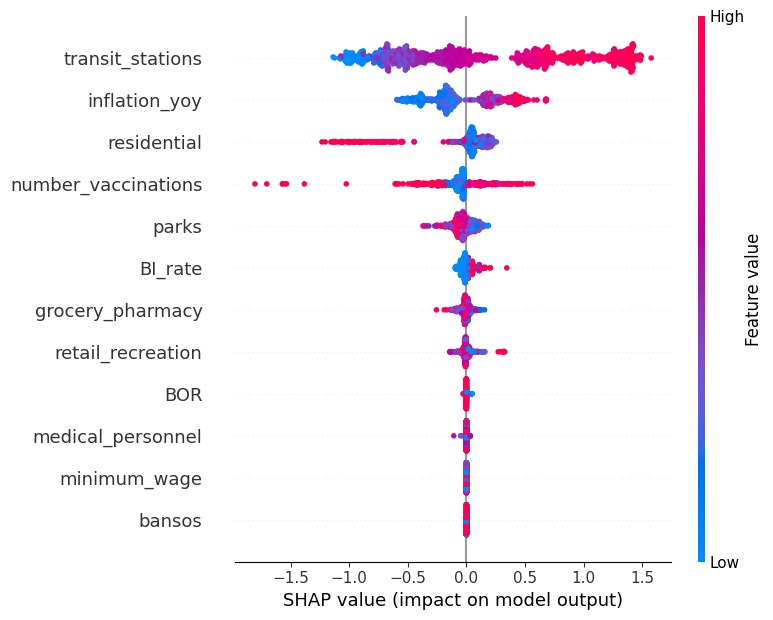

In [ ]:
# Explain with tree SHAP for DIFF_IHSG Variable (Y6)
explainer_Y6 = shap.TreeExplainer(regrY6)
shap_values_Y6 = explainer_Y6.shap_values(X_Y6)
shap.summary_plot(shap_values_Y6, X_Y6, feature_names=X_features_name)

In [ ]:
shap.initjs()
shap.force_plot(explainer_Y6.expected_value, shap_values_Y6, feature_names=X_features_name)

## Save Data for Use in the Novelty SHAPPI

In [ ]:
import joblib

data_saved = {
    'X' : X,
    'X_Y1' : X_Y1,
    'X_Y2' : X_Y2,
    'X_Y3' : X_Y3,
    'X_Y4' : X_Y4,
    'X_Y5' : X_Y5,
    'X_Y6' : X_Y6,
    'Y1' : Y1,
    'Y2' : Y2,
    'Y3' : Y3,
    'Y4' : Y4,
    'Y5' : Y5,
    'Y6' : Y6,
    'regrY1' : regrY1,
    'regrY2' : regrY2,
    'regrY3' : regrY3,
    'regrY4' : regrY4,
    'regrY5' : regrY5,
    'regrY6' : regrY6,
    'n_dim_X_features' : n_dim_X_features,
    'n_dim_Y_features' : n_dim_Y_features,
    'X_features_name' : X_features_name,
    'Y_features_name' : Y_features_name,
    'shap_values_Y1' : shap_values_Y1,
    'shap_values_Y2' : shap_values_Y2,
    'shap_values_Y3' : shap_values_Y3,
    'shap_values_Y4' : shap_values_Y4,
    'shap_values_Y5' : shap_values_Y5,
    'shap_values_Y6' : shap_values_Y6
}

joblib.dump(data_saved, folder_drive + 'data_ga_saved1.job')

['/content/drive/MyDrive/data_ga_saved1.job']